# Precificação de quartos de hotéis

In [1]:
import pandas as pd

dados = pd.read_csv('hoteis.csv')
dados.head()

,Estrelas,ProximidadeTurismo,Capacidade,Preco
0,5,9.301565,3,506.275452
1,1,1.785891,1,246.363458
2,4,15.504293,3,325.873550
3,4,4.173188,3,521.343284
4,4,9.443685,1,252.587087


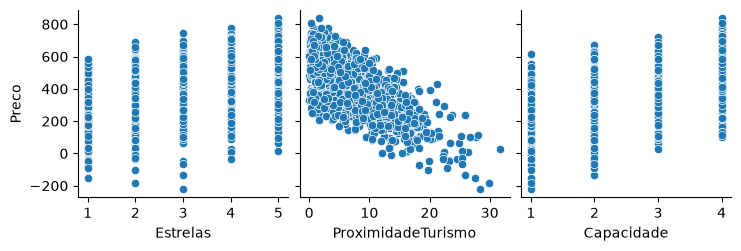

In [3]:
import seaborn as sns

sns.pairplot(dados, x_vars=['Estrelas', 'ProximidadeTurismo', 'Capacidade'], y_vars='Preco')

In [4]:
from sklearn.model_selection import train_test_split

x = dados[['Estrelas', 'ProximidadeTurismo', 'Capacidade']]
y = dados['Preco']
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size=0.3, random_state=230)

In [6]:
import statsmodels.api as sm

treino_x = sm.add_constant(treino_x)

In [8]:
modelo_1 = sm.OLS(treino_y, treino_x).fit()
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     2828.
Date:                Thu, 23 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:13:55   Log-Likelihood:                -3689.2
No. Observations:                 700   AIC:                             7386.
Df Residuals:                     696   BIC:                             7405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                195.1576      6

In [9]:
modelo_2 = sm.OLS(treino_y, treino_x[['const', 'Capacidade', 'ProximidadeTurismo']]).fit()
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     1066.
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          9.00e-213
Time:                        17:15:13   Log-Likelihood:                -4101.7
No. Observations:                 700   AIC:                             8209.
Df Residuals:                     697   BIC:                             8223.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                355.0018      9

In [10]:
modelo_3 = sm.OLS(treino_y, treino_x[['Estrelas', 'const', 'Capacidade']]).fit()
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     281.1
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           3.01e-90
Time:                        17:16:46   Log-Likelihood:                -4385.0
No. Observations:                 700   AIC:                             8776.
Df Residuals:                     697   BIC:                             8790.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Estrelas      50.3893      3.446     14.621      0.0

In [11]:
print("R²")
print('modelo 1:', modelo_1.rsquared)
print('modelo 2:', modelo_2.rsquared)
print('modelo 3:', modelo_3.rsquared)

R²
modelo 1: 0.9241850901112033
modelo 2: 0.7536532740101605
modelo 3: 0.44649104153622887


In [ ]:
# o modelo 1 aparenta ser o melhor modelo, pois possui o maior R², ou seja, explica melhor a variação do preço dos hotéis. 
# Além disso, todos os coeficientes são significativos, indicando que todas as variáveis independentes contribuem para a explicação do preço.
# Por último, ele não apresenta multicolinearidade, o que é um bom indicativo de que as variáveis independentes não estão correlacionadas entre si.